# Step 6 - Analysis (Single + Compare)


**How this notebook is organized**

1. Select a cell/tune and resolve run(s).
2. Output plots (single or compare).
3. Input plots (single or compare).
4. Synapse plots (planned).
5. Extra analysis (tables + special cases).

Analysis logic lives in `modules_local/analysis/analysis.py`, and plotting in `modules_local/analysis/plotting.py`.
See `modules_local/analysis/README.md` for UI notes and defaults.


## 1. Select runs


In [1]:
# --------------------------
# Defaults (manual mode)
# --------------------------
cell_name = "SST"      # SST, SST_0, PV, PN

tunes_dir = "tunes"
model_dir = "seg_tuned"

run_single_stem = "latest"
run_compare_a = "latest"
run_compare_b = "previous"  # use "none" to disable comparison
compare_a_path = ""
compare_b_path = ""

In [2]:
# --------------------------
# Defaults (from config)
# --------------------------
from pathlib import Path
import json
from modules_local import analysis

_defaults_path = analysis.find_scp_root(Path.cwd()).resolve() / "modules_local" / "analysis" / "analysis_defaults.json"
_defaults = json.loads(_defaults_path.read_text())

for _k in ("plot_window", "input_plot_window"):
    if isinstance(_defaults.get(_k), list) and len(_defaults[_k]) == 2:
        _defaults[_k] = (_defaults[_k][0], _defaults[_k][1])

globals().update(_defaults)


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport
--No graphics will be displayed.


In [3]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from modules_local import run_sim
from modules_local.analysis import plotting, analysis, analysis_ui

BASE_DIR = analysis.find_scp_root(Path.cwd()).resolve()
CELLS_DIR = BASE_DIR / "cells"

# Widgets (optional)
use_widgets = True
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAVE_WIDGETS = True
except Exception:
    _HAVE_WIDGETS = False


In [4]:
# Selection UI
analysis_ui.build_selection_ui(globals())

# (optional) quick selection check
analysis_ui.get_selection_from_globals(globals())

"/home/hrbncv/SCP/external_data/PV_scatt_peak.csv@300" ",25"
"/home/hrbncv/SCP/external_data/PV_scatt_avg.csv" ",6"
"/home/hrbncv/SCP/external_data/SST_scatt_peak.csv@500" ",20"
"/home/hrbncv/SCP/external_data/SST_scatt_avg.csv" ",4"

Textarea(value='/home/hrbncv/SCP/external_data/SSTFiringRateAvg.csv@525.0;color=k;linestyle=--', description='…

Output()

'/home/hrbncv/SCP/external_data/SST_scatt_avg.csv,4'

## 2. Output plots (standard)


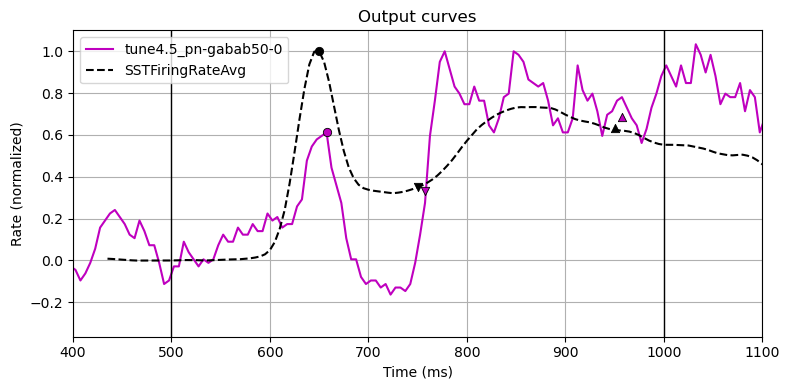

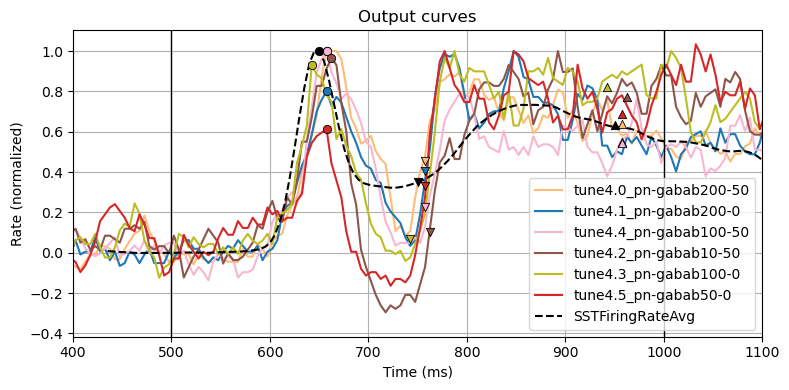

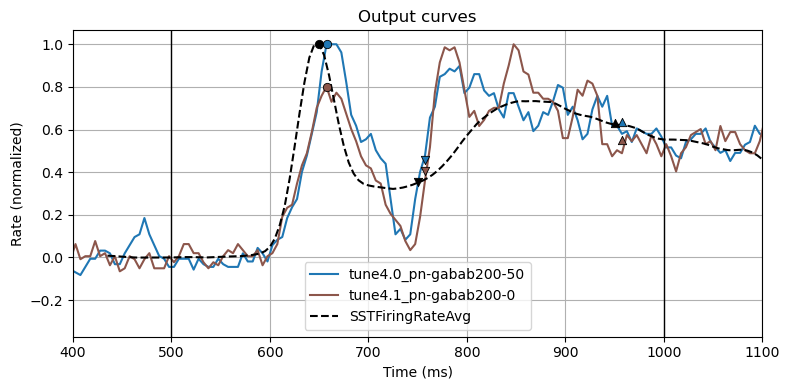

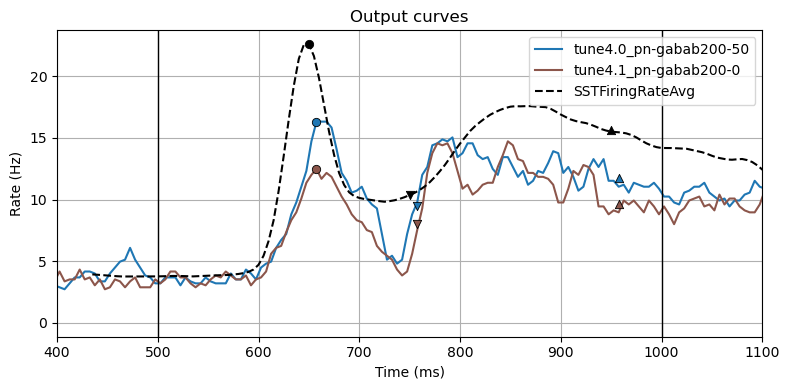

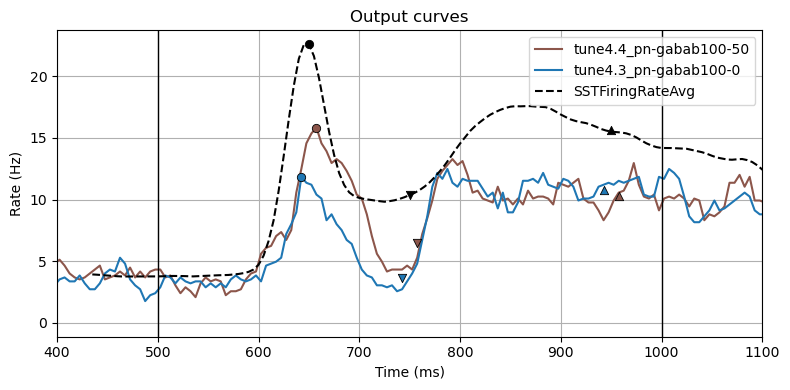

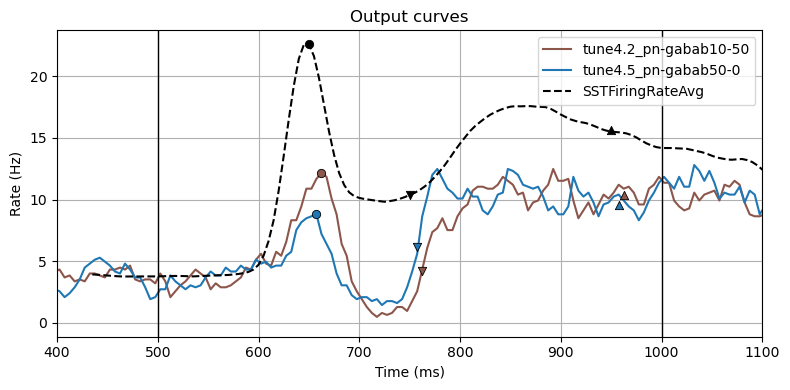

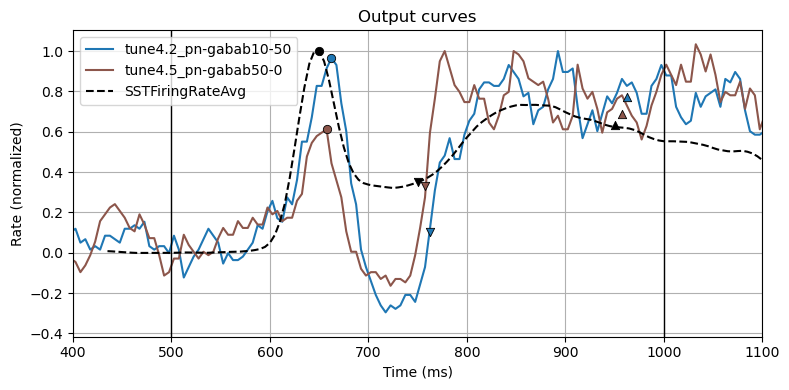

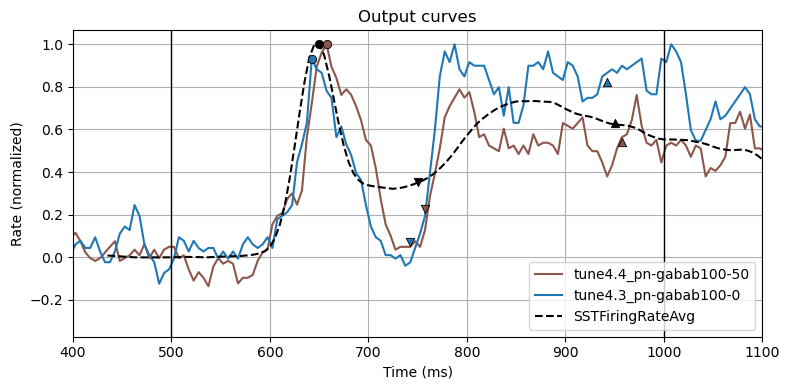

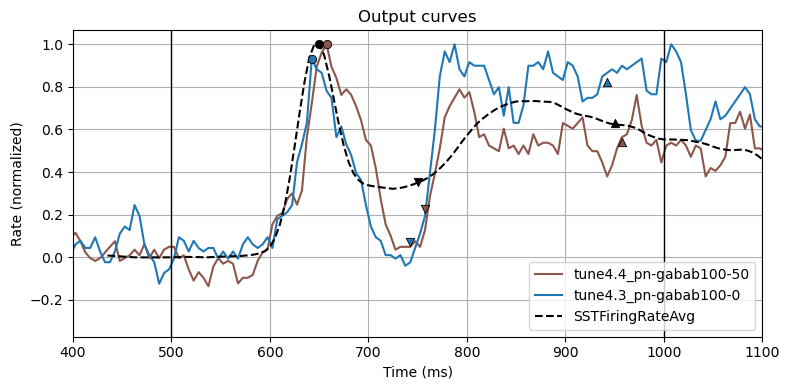

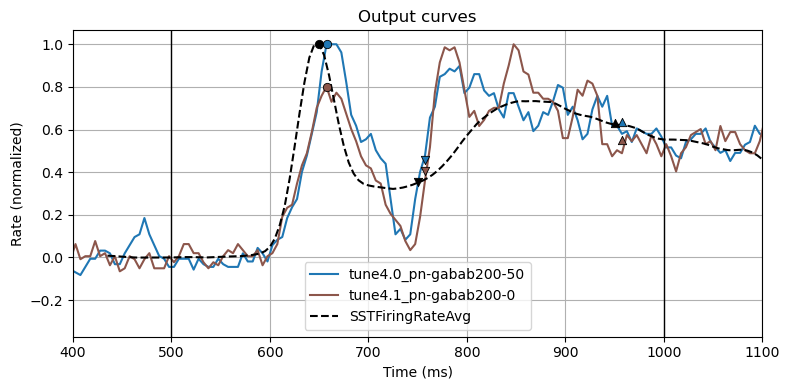

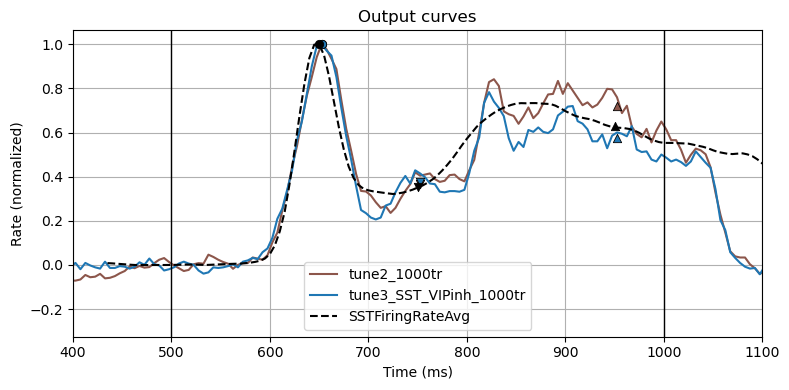

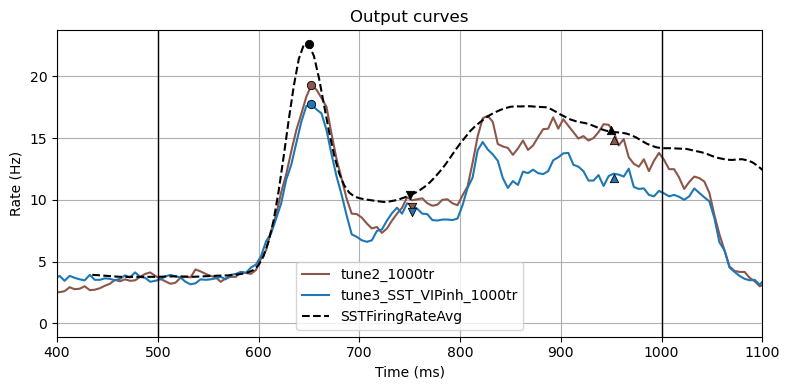

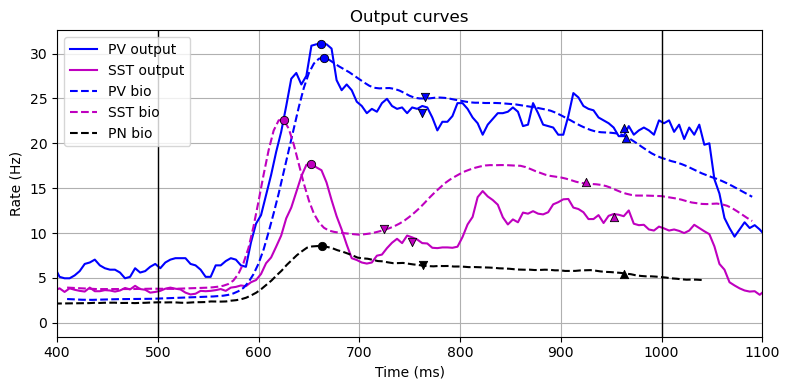

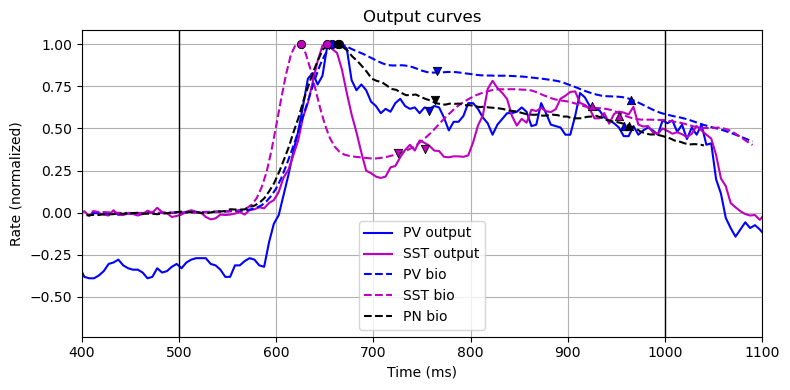

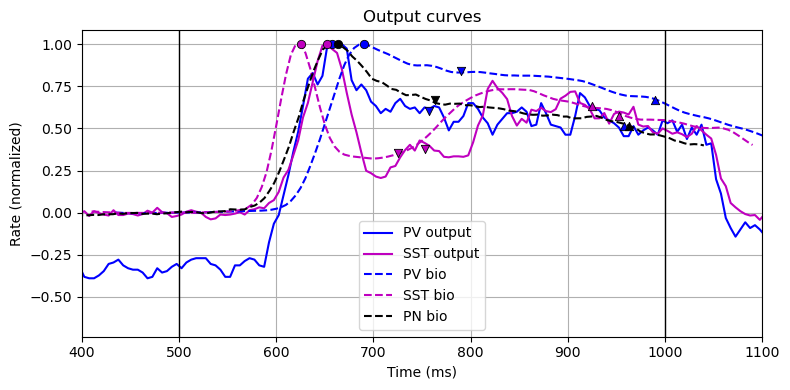

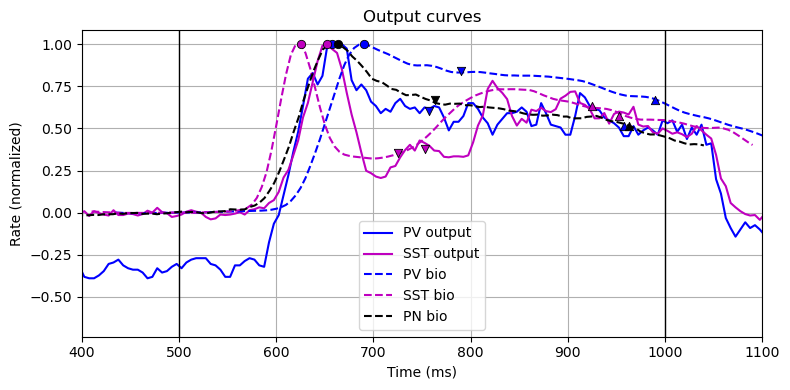

In [5]:
# Outputs UI (single or compare)
analysis_ui.build_outputs_ui(globals())


## 3. Input plots (standard)


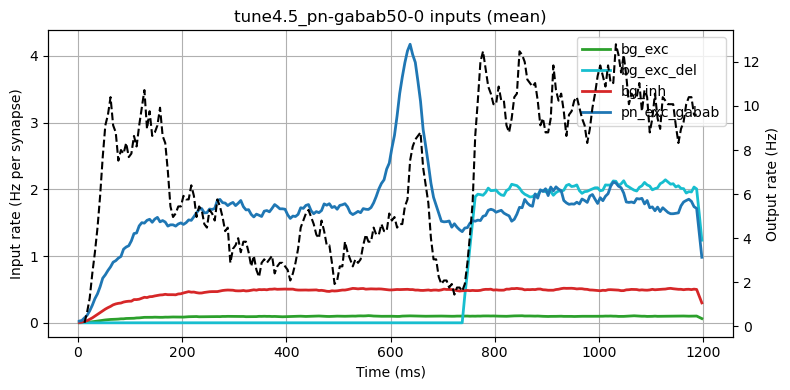

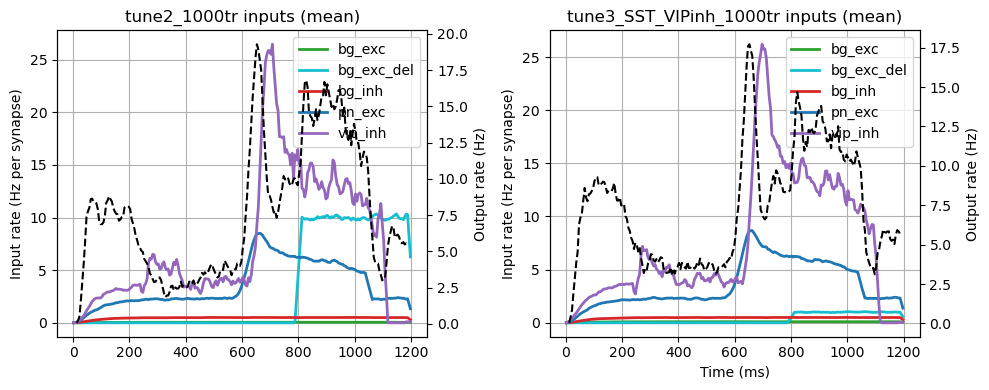

In [6]:
# Inputs UI (single or compare)
analysis_ui.build_inputs_ui(globals())


## 4. Synapse plots (planned)


## 5. Extra analysis (tables + special cases)


In [7]:
# Extra analysis UI
analysis_ui.get_selection_from_globals(globals())
analysis_ui.build_extra_ui(globals())


In [8]:
# # Manual: single-run tables (extra)
# analysis_ui.run_extra_tables_from_globals(globals())


### Output metrics (bio)


In [9]:
metrics = analysis_ui.run_output_metrics_from_globals(globals())
if metrics:
    show_params = bool(globals().get("output_metrics_show_params", True))
    ref_label = globals().get("output_metrics_ref_label")
    show_delta = bool(globals().get("output_metrics_show_delta", False))
    highlight_best = bool(globals().get("output_metrics_highlight_best", False))
    show_params = bool(globals().get("output_metrics_show_params", True))
    if isinstance(metrics, dict) and all(isinstance(v, dict) for v in metrics.values()):
        analysis_ui.show_md(analysis_ui.format_output_metrics_tables_columns(metrics, title="Output metrics", show_params=show_params, reference_label=ref_label, show_deltas=show_delta, highlight_best=highlight_best))
    else:
        sel = analysis_ui.get_selection_from_globals(globals())
        label = analysis.run_label(analysis.resolve_run(sel["base"], sel["run_single"]))
        analysis_ui.show_md(analysis_ui.format_output_metrics_tables(metrics, title=f"Output metrics ({label})", show_params=show_params))


### Output metrics
| Metric | tune4.5_pn-gabab50-0 | SSTFiringRateAvg |
| --- | --- | --- |
| **baseline_mean** | 2.99 | 3.77 |
| **peak_rate_hz_raw** | 8.8 | 22.6 |
| peak_rate_hz | 0.612 |  |
| peak_value | 0.612 |  |
| **peak_latency_ms** | 158 | 150 |
| drop_value | 0.331 | 0.352 |
| **drop_pct** | 46 | 64.8 |
| rebound_value | 0.688 | 0.631 |
| **rebound_pct** | -12.4 | 36.9 |
| **auc** | 0.212 | 0.225 |

### Output metrics (params)
| Metric | tune4.5_pn-gabab50-0 | SSTFiringRateAvg |
| --- | --- | --- |
| peak_window_ms | 200 | 200 |
| drop_window_ms | 100 | 100 |
| auc_window | stim | stim |
| pdp_mode | window | window |
| pdp_window_ms | 50 | 50 |
| stim_start_ms | 500 | 500 |
| stim_stop_ms | 1e+03 | 1e+03 |
| peak_time_ms | 658 | 650 |
| drop_time_ms | 758 | 750 |
| rebound_window_ms | 300 | 300 |
| rebound_time_ms | 958 | 950 |
| auc_units | normalized*s | normalized*s |
| baseline_ms | 50 | 50 |
| baseline_mode | window | window |
| baseline_time_ms | 500 | 500 |
| baseline_center_ms | 0 | 0 |
| baseline_window_start_ms | 475 | 475 |
| baseline_window_stop_ms | 525 | 525 |
| norm_mode | peak | peak |
| norm_window | stim | stim |
| norm_scale | 9.49 | 18.8 |
| avg_norm_scale |  |  |
| drop_center_ms | 758 | 750 |
| drop_window_start_ms | 732 | 725 |
| drop_window_stop_ms | 782 | 775 |
| rebound_center_ms | 958 | 950 |
| rebound_window_start_ms | 932 | 925 |
| rebound_window_stop_ms | 982 | 975 |

### Spike stats (optional)


In [10]:
# # Manual: spike stats (extra)
# analysis_ui.run_spike_stats_from_globals(globals())


### 5.1 Comparison tables + synapse compare plots (optional)


In [11]:
# # Manual: comparison tables + synapse compare plots (extra)
# analysis_ui.run_extra_compare_from_globals(globals())


### 4.2 Snapshot compare tables (optional)


In [12]:
# # Manual: snapshot compare tables (extra)
# analysis_ui.run_snapshot_compare_from_globals(globals())


### 4.3 IClamp analysis (optional)


In [13]:
# # Manual: IClamp analysis (extra)
# analysis_ui.run_iclamp_analysis_from_globals(globals())
